## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

## Step 2: Load the Dataset

In [2]:
# Load the digits dataset
digits = load_digits()

# Features: pixel intensities of 8x8 images
X = digits.data
y = digits.target

print("Dataset Description:")
print("=" * 50)
print(f"Total Samples  : {X.shape[0]}")
print(f"Total Features : {X.shape[1]}  (8x8 = 64 pixel values per image)")
print(f"Classes        : {digits.target_names}  (digits 0-9)")
print(f"X shape        : {X.shape}")
print(f"y shape        : {y.shape}")

Dataset Description:
Total Samples  : 1797
Total Features : 64  (8x8 = 64 pixel values per image)
Classes        : [0 1 2 3 4 5 6 7 8 9]  (digits 0-9)
X shape        : (1797, 64)
y shape        : (1797,)


## Step 3: Explore the Data

In [3]:
# Convert to DataFrame for tabular view
X_df = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(64)])
X_df['label'] = y

print("head() — First 5 rows (pixel values):")
display(X_df.head())

head() — First 5 rows (pixel values):


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [4]:
print("tail() — Last 5 rows:")
display(X_df.tail())

tail() — Last 5 rows:


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9
1796,0.0,0.0,10.0,14.0,8.0,1.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,8.0,12.0,14.0,12.0,1.0,0.0,8


In [5]:
print("describe() — Statistical Summary:")
display(X_df.drop(columns=['label']).describe())

describe() — Statistical Summary:


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [6]:
print("Dataset Info:")
X_df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 n

In [7]:
print("Missing values per column:")
print(X_df.isnull().sum().sum(), "— No missing values!")

Missing values per column:
0 — No missing values!


## Step 4: Visualize Sample Digit Images

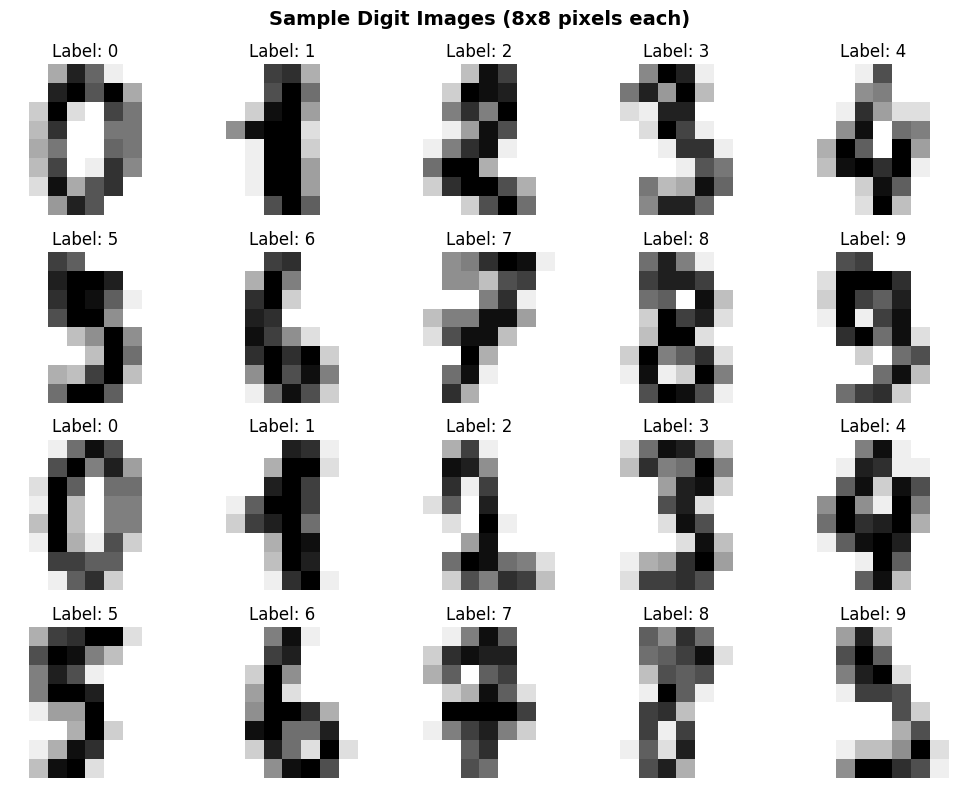

In [8]:
# Plot a sample of 20 digit images from the dataset
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Label: {digits.target[i]}', fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Digit Images (8x8 pixels each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Target Variable Distribution

Class Distribution (digit counts):
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


C:\Users\ndhee\AppData\Local\Temp\ipykernel_27288\1107979347.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='tab10')


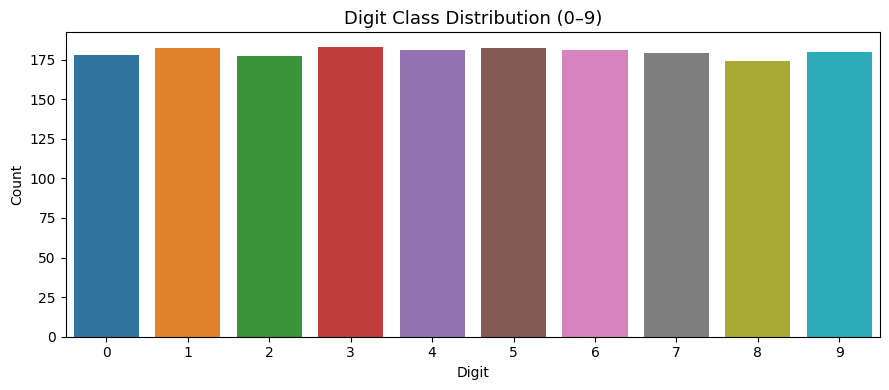

In [9]:
print("Class Distribution (digit counts):")
print(pd.Series(y).value_counts().sort_index())

plt.figure(figsize=(9, 4))
sns.countplot(x=y, palette='tab10')
plt.title('Digit Class Distribution (0–9)', fontsize=13)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

## Step 6: Visualize Average Image Per Digit

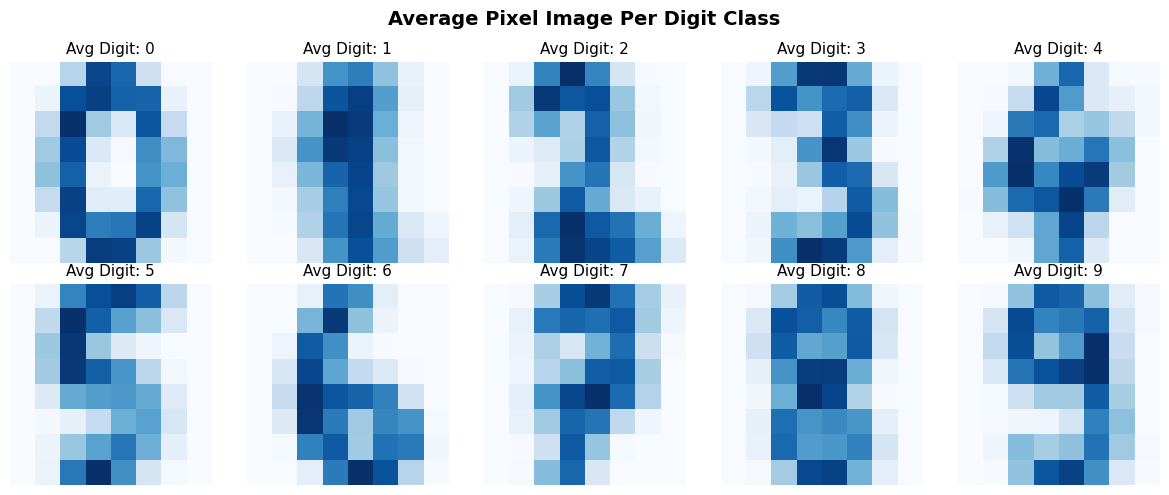

In [10]:
# Show the average (mean) image for each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    avg_image = X[y == digit].mean(axis=0).reshape(8, 8)
    axes[digit].imshow(avg_image, cmap='Blues', interpolation='nearest')
    axes[digit].set_title(f'Avg Digit: {digit}', fontsize=11)
    axes[digit].axis('off')

plt.suptitle('Average Pixel Image Per Digit Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nClass distribution in train set:")
print(pd.Series(y_train).value_counts().sort_index().to_dict())

Training set : (1437, 64)
Test set     : (360, 64)

Class distribution in train set:
{0: 142, 1: 146, 2: 142, 3: 146, 4: 145, 5: 145, 6: 145, 7: 143, 8: 139, 9: 144}


## Step 8: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"Pixel mean (before scaling): {X_train.mean():.3f}")
print(f"Pixel mean (after scaling) : {X_train_scaled.mean():.6f}")

StandardScaler applied.
Pixel mean (before scaling): 4.895
Pixel mean (after scaling) : 0.000000


## Step 9: Train Logistic Regression Model

In [ ]:
# Train Logistic Regression with multi-class support
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42
)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Number of classes : {model.classes_}")
print(f"Coefficient shape : {model.coef_.shape}  (10 classes x 64 pixels)")

Model trained successfully!
Number of classes : [0 1 2 3 4 5 6 7 8 9]
Coefficient shape : (10, 64)  (10 classes x 64 pixels)


c:\Users\ndhee\mlpractice\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Step 10: Make Predictions

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

print("Sample Predictions (first 15):")
print("Predicted:", y_pred[:15])
print("Actual   :", y_test[:15])

# Show prediction probabilities for first 5 samples
prob_df = pd.DataFrame(y_prob[:5], columns=[f'P(digit={i})' for i in range(10)])
prob_df.index = [f'Sample {i}' for i in range(5)]
print("\nPrediction Probabilities (first 5 samples):")
display(prob_df.round(3))

Sample Predictions (first 15):
Predicted: [5 2 8 8 7 2 6 2 6 5 0 5 9 3 4]
Actual   : [5 2 8 1 7 2 6 2 6 5 0 5 9 3 4]

Prediction Probabilities (first 5 samples):


,P(digit=0),P(digit=1),P(digit=2),P(digit=3),P(digit=4),P(digit=5),P(digit=6),P(digit=7),P(digit=8),P(digit=9)
Sample 0,0.000,0.000,0.000,0.000,0.000,0.918,0.000,0.000,0.000,0.081
Sample 1,0.000,0.000,0.996,0.001,0.000,0.001,0.000,0.000,0.002,0.000
Sample 2,0.000,0.066,0.000,0.001,0.001,0.000,0.003,0.003,0.915,0.009
Sample 3,0.005,0.218,0.003,0.000,0.005,0.007,0.173,0.014,0.575,0.002
Sample 4,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.999,0.000,0.000


## Step 11: Model Evaluation — Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 97.22%


## Step 12: Classification Report

In [ ]:
print("Classification Report (per digit):")
print(classification_report(
    y_test, y_pred,
    target_names=[f'Digit {i}' for i in range(10)]
))

Classification Report (per digit):
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00        36
     Digit 1       0.89      0.89      0.89        36
     Digit 2       1.00      1.00      1.00        35
     Digit 3       0.97      1.00      0.99        37
     Digit 4       0.97      1.00      0.99        36
     Digit 5       1.00      1.00      1.00        37
     Digit 6       1.00      0.97      0.99        36
     Digit 7       1.00      1.00      1.00        36
     Digit 8       0.89      0.89      0.89        35
     Digit 9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



## Step 13: Confusion Matrix

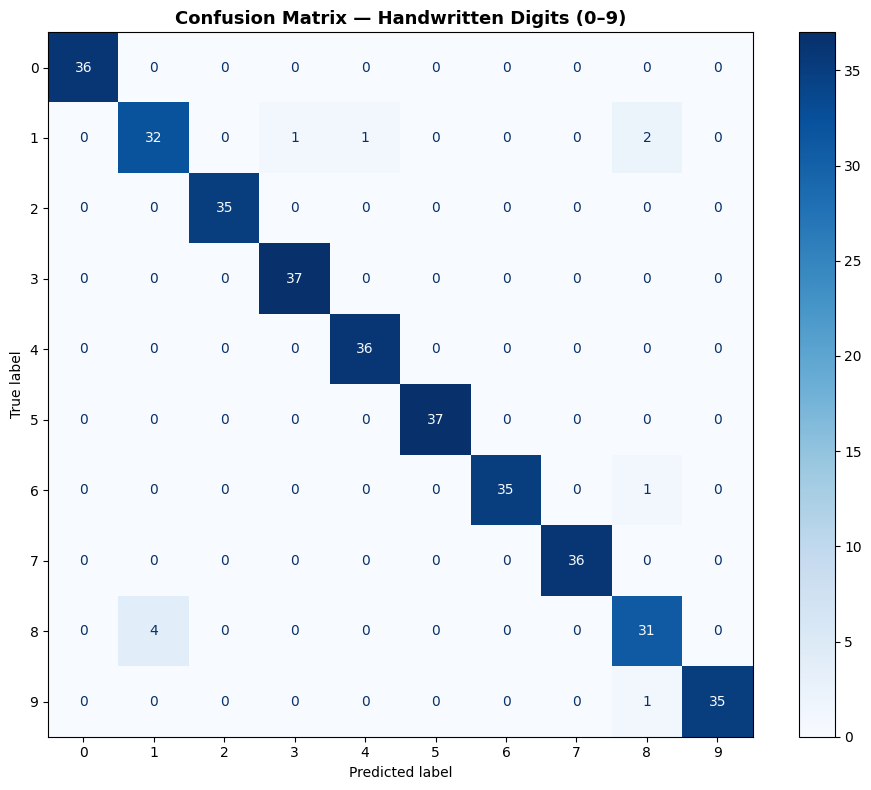


Diagonal = Correct predictions per digit


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=digits.target_names)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=True)
plt.title('Confusion Matrix — Handwritten Digits (0–9)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDiagonal = Correct predictions per digit")

## Step 14: Visualize Misclassified Digits

Total misclassified: 10 out of 360


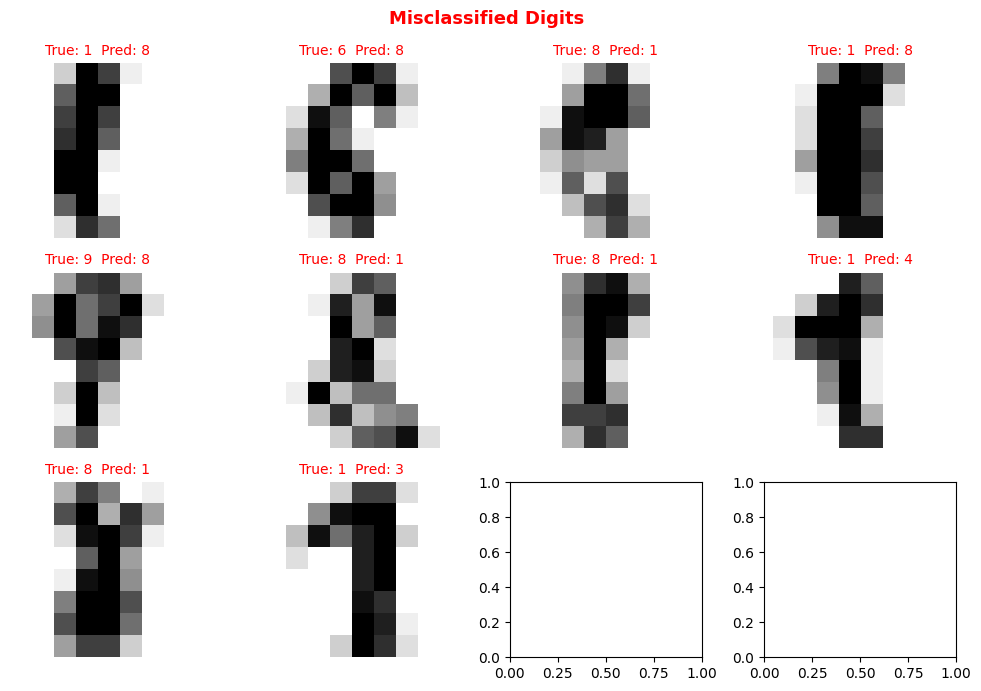

In [ ]:
# Find misclassified samples
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_test)}")

# Plot first 12 misclassified digits
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:12]):
    # Get original image from test set
    img = X_test[idx].reshape(8, 8)
    axes[i].imshow(img, cmap='gray_r', interpolation='nearest')
    axes[i].set_title(
        f'True: {y_test[idx]}  Pred: {y_pred[idx]}',
        color='red', fontsize=10
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Digits', fontsize=13, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

## Step 15: Feature Importance — Most Influential Pixels

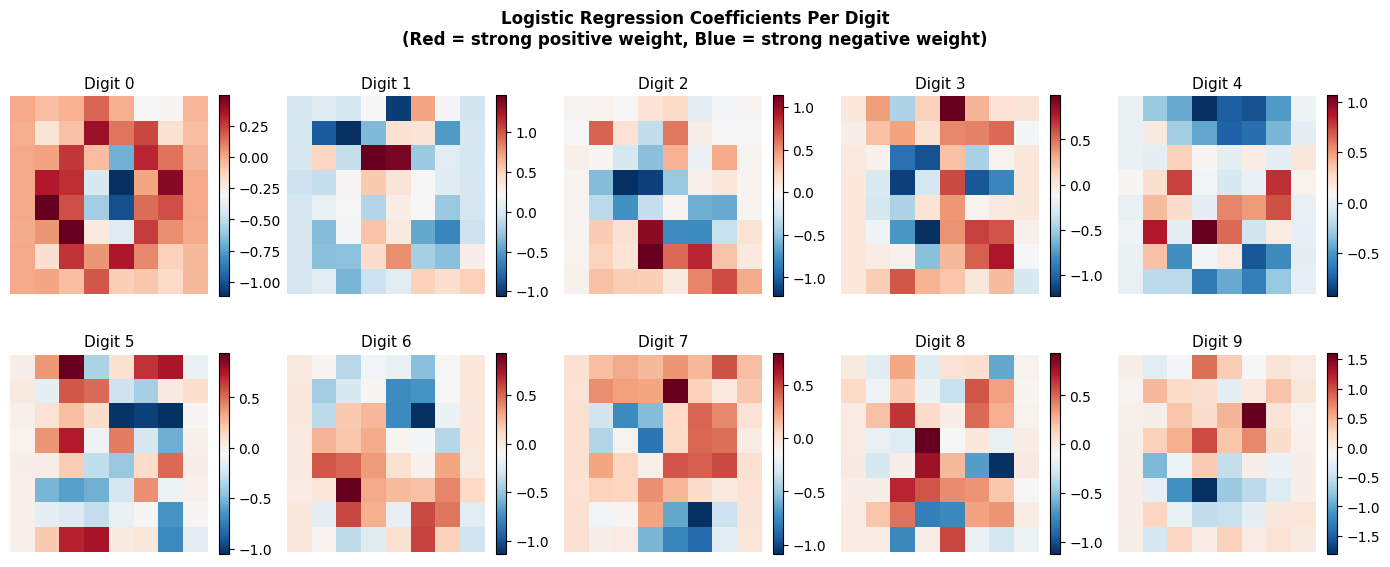

In [ ]:
# Show which pixels matter most for classifying each digit
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for digit in range(10):
    coef_img = model.coef_[digit].reshape(8, 8)
    im = axes[digit].imshow(coef_img, cmap='RdBu_r', interpolation='nearest')
    axes[digit].set_title(f'Digit {digit}', fontsize=11)
    axes[digit].axis('off')
    plt.colorbar(im, ax=axes[digit], fraction=0.046)

plt.suptitle(
    'Logistic Regression Coefficients Per Digit\n'
    '(Red = strong positive weight, Blue = strong negative weight)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()